In [1]:
from sklearn.datasets import fetch_openml 

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)

In [3]:
X, y = mnist.data, mnist.target

In [4]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [5]:
X.shape

(70000, 784)

In [6]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [7]:
y.shape

(70000,)

In [9]:
import matplotlib.pyplot as plt

In [10]:
def plot_digit(image_data):
    image = image_data.reshape(28,28) 
    plt.imshow(image, cmap='binary')
    plt.axis("off")

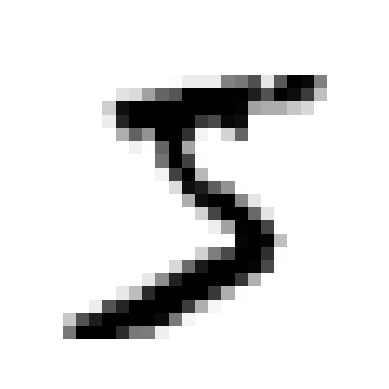

In [11]:
some_digit = X[0] 
plot_digit(some_digit) 
plt.show()

In [12]:
y[0]

'5'

In [13]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [14]:
y_train_5 = (y_train == '5') # True for all 5s, False for all other digits 
y_test_5 = (y_test == '5')

In [15]:
from sklearn.linear_model import SGDClassifier

In [16]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [17]:
sgd_clf.predict([some_digit])

array([ True])

In [18]:
from sklearn.model_selection import cross_val_score

In [19]:
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [20]:
from sklearn.dummy import DummyClassifier

In [23]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) #  prints False: no 5s detected

False


In [25]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

In [28]:
from sklearn.model_selection import cross_val_predict

In [29]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [30]:
from sklearn.metrics import confusion_matrix

In [31]:
cm = confusion_matrix(y_train_5, y_train_pred)

In [32]:
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

In [33]:
y_train_perfect_predictions = y_train_5

In [34]:
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]], dtype=int64)

In [35]:
from sklearn.metrics import precision_score, recall_score

In [36]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [37]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [38]:
from sklearn.metrics import f1_score

In [39]:
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [40]:
y_scores = sgd_clf.decision_function([some_digit])

In [41]:
y_scores

array([2164.22030239])

In [42]:
threshold = 0

In [43]:
y_some_digit_pred = (y_scores > threshold)

In [44]:
y_some_digit_pred

array([ True])

In [46]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [47]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')

In [48]:
from sklearn.metrics import precision_recall_curve

In [49]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores) 

In [61]:
from matplotlib.axes import Axes

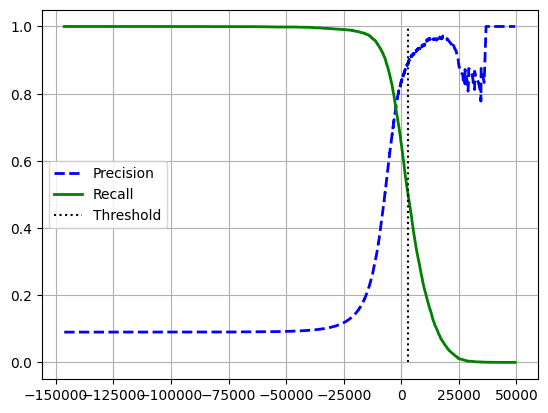

In [73]:
plt.plot(thresholds, precisions[:-1], "b--", label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label='Recall', linewidth=2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label='Threshold')
plt.grid()
plt.legend()
plt.show()

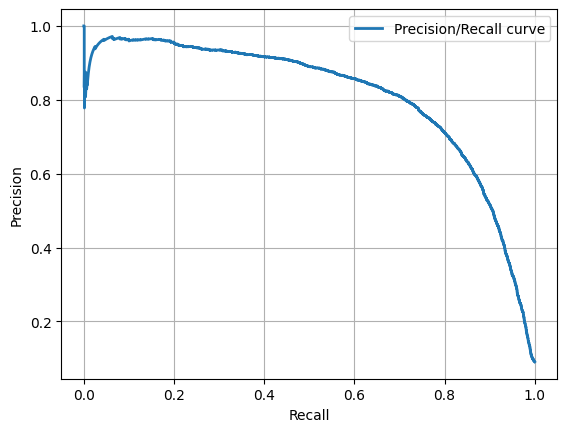

In [90]:
plt.plot(recalls, precisions, linewidth=2, label='Precision/Recall curve')
plt.legend() 
plt.grid()
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()

In [78]:
idx_for_90_precision = (precisions >= 0.90).argmax()

In [79]:
threshold_for_90_precision = thresholds[idx_for_90_precision]

In [80]:
threshold_for_90_precision

3370.0194991439594

In [81]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [82]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [83]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)

In [84]:
recall_at_90_precision

0.4799852425751706

In [91]:
from sklearn.metrics import roc_curve

In [92]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [93]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()

In [94]:
trp_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

In [103]:
import numpy as np

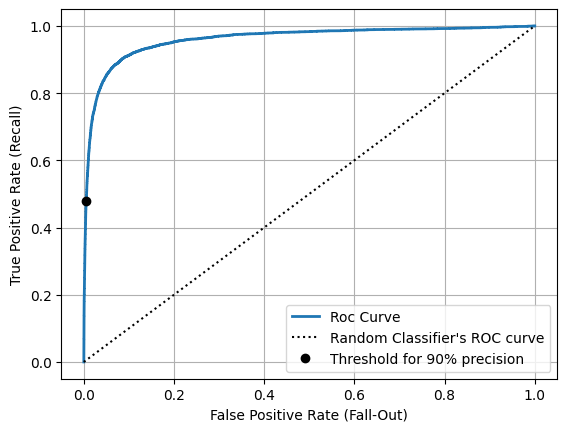

In [107]:
plt.plot(fpr,tpr, linewidth=2, label='Roc Curve')
plt.plot([0,1],[0,1], 'k:', label="Random Classifier's ROC curve")
plt.plot([fpr_90], [trp_90], 'ko', label="Threshold for 90% precision")
plt.xticks(np.arange(0,1.2,0.2))
plt.legend()
plt.grid()
plt.ylabel("True Positive Rate (Recall)")
plt.xlabel("False Positive Rate (Fall-Out)")
plt.show()

In [108]:
from sklearn.metrics import roc_auc_score

In [109]:
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [111]:
from sklearn.ensemble import RandomForestClassifier

In [112]:
forest_clf = RandomForestClassifier(random_state=42)

In [113]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

In [114]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [115]:
y_scores_forest = y_probas_forest[:,1] 
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

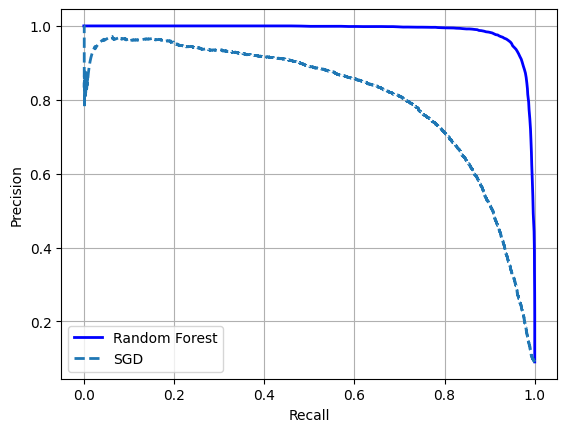

In [116]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest") 
plt.plot(recalls, precisions, "--", linewidth=2, label='SGD')
plt.legend()
plt.grid() 
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()

In [117]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5 # positive proba > 50%

In [118]:
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [119]:
roc_auc_score(y_train_5,y_train_pred_forest)

0.9358174809192218

In [120]:
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [121]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

In [123]:
from sklearn.svm import SVC

In [124]:
svm_clf = SVC(random_state=42)

In [125]:
svm_clf.fit(X_train[:2000], y_train[:2000]) # y_train not y_train_5

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [126]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [127]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [128]:
class_id = some_digit_scores.argmax() 
class_id

5

In [129]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [130]:
svm_clf.classes_[class_id]

'5'

In [131]:
from sklearn.multiclass import OneVsRestClassifier

In [132]:
ovr_clf = OneVsRestClassifier(SVC(random_state=42)) 
ovr_clf.fit(X_train[:2000], y_train[:2000])

,estimator,SVC(random_state=42)
,n_jobs,None
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001


In [133]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [134]:
len(ovr_clf.estimators_)

10

In [135]:
sgd_clf = SGDClassifier(random_state=42)

In [136]:
sgd_clf.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [137]:
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [138]:
sgd_clf.decision_function([some_digit]).round()

array([[-31893., -34420.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

In [139]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

In [140]:
from sklearn.preprocessing import StandardScaler